# 32 · The Ranker — XGBoost on Pooled Candidates

**Purpose.** Stage two. Notebook 30 fixed the pool (48.9% of all label pairs
reachable); the best solo heuristic converts only 7.2% into top-10 placements.
This notebook trains the model whose entire job is to convert pool membership
into rank — the ~7× headroom the architecture was built to capture.

## The statistical object

For every pooled candidate, estimate

$$p_{ui}(t) = P\big(i \in B_u(t,\,t{+}30] \mid X_u(t),\ Z_i(t),\ W_{ui}(t)\big)$$

then deploy the **ordering**: recommend $\arg\max^{(10)}_i \hat p_{ui}$ per
household. The prediction is a probability; the product is a permutation.

## Why XGBoost, specifically

- **Tabular, mixed-type, interaction-heavy features** — the regime where
  gradient-boosted trees still beat neural nets.
- **Native missing handling** — learns a default direction per split, so
  "never bought this item" (NaN recency, 13.9% of rows) is used as signal
  rather than imputed away.
- **Non-linear, non-monotone structure** — the due-ness relationship and the
  times_bought cliff (1 vs 2+) are exactly what trees capture without
  hand-crafted transforms.
- **Gradient boosting = gradient descent in function space** — first and
  second derivatives of the loss w.r.t. *predictions* (not parameters), each
  new tree fitted to those gradients. That's why a piecewise-constant model
  can still be trained by a gradient method.

## Pointwise, not pairwise (a deliberate choice)

We train `binary:logistic` on independent (household, product) rows rather
than `rank:ndcg` on grouped lists. Reasons: the scores stay interpretable as
probabilities (needed for expected-value re-ranking later), training is
simpler and more stable, and ranking within a household is invariant to any
monotone transform of a well-fit probability. LambdaMART is noted as the
upgrade path if the evaluation says list-level optimization is worth it.

## No class reweighting

Positives are ~4.2%. We do **not** set `scale_pos_weight`: ranking only needs
correct *ordering* within a household, and reweighting destroys calibration
for no ranking gain. (In credit-risk terms: we want a calibrated PD, not a
balanced one.)

## Protocol

Train on the three stacked planes (450/510/570), early-stop on the validation
plane (600) by AUC-PR, then score the day-600 pool, rank per household, cut at
K=10, and compare against the accumulated leaderboard on identical labels.
Day 650 stays sealed for notebook 90.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import yaml
from pathlib import Path

from retail_ds.evaluate.metrics import recall_at_k, hit_rate_at_k, ndcg_at_k

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parents[1]

CFG = yaml.safe_load((ROOT / "configs" / "base.yaml").read_text())
K = CFG["top_k"]
OUT_DIR = ROOT / "data" / "processed"

train = pd.read_parquet(OUT_DIR / "ranker_train.parquet")
valid = pd.read_parquet(OUT_DIR / "ranker_valid.parquet")

# gap_source is a string flag for how the product clock was estimated -> ordinal code
quality = {"product": 3, "sub_commodity": 2, "commodity": 1, "global": 0}
for df in (train, valid):
    df["gap_quality"] = df["gap_source"].map(quality).fillna(0).astype(np.int8)

DROP = ["household_key", "product_id", "asof_day", "label", "gap_source"]
FEATURES = [c for c in train.columns if c not in DROP]

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 4.5)

print(f"train {train.shape} | valid {valid.shape}")
print(f"positives: train {train['label'].mean():.3%} | valid {valid['label'].mean():.3%}")
print(f"{len(FEATURES)} features:", FEATURES)

train (3586935, 26) | valid (1358184, 26)
positives: train 4.231% | valid 3.838%
21 features: ['in_als_new', 'in_buy_again', 'in_popularity', 'times_bought', 'days_since_last', 'due_ness', 'hh_days_since_last', 'tenure_days', 'baskets_30d', 'baskets_90d', 'baskets_365d', 'spend_30d', 'spend_365d', 'products_90d', 'avg_basket_value', 'item_baskets_365d', 'item_households_365d', 'item_avg_price', 'median_gap_days', 'als_affinity', 'gap_quality']


In [2]:
model = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",
    eval_metric="aucpr",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    train[FEATURES], train["label"],
    eval_set=[(valid[FEATURES], valid["label"])],
    verbose=100,
)
print("best iteration:", model.best_iteration, "| best AUC-PR:", round(model.best_score, 4))

[0]	validation_0-aucpr:0.28379
[100]	validation_0-aucpr:0.30191
[183]	validation_0-aucpr:0.30191
best iteration: 133 | best AUC-PR: 0.3022


In [3]:
import duckdb
con = duckdb.connect((ROOT / "db" / "retail.duckdb").as_posix(), read_only=True)
AS_OF = CFG["snapshots"]["valid"]
labels = con.sql(f"SELECT household_key, product_id FROM purchase_labels({AS_OF}, 30)").df()

scored = valid[["household_key", "product_id"]].copy()
scored["score"] = model.predict_proba(valid[FEATURES])[:, 1]
scored["rank"] = (scored.groupby("household_key")["score"]
                  .rank(method="first", ascending=False).astype(int))
ranker_recs = scored[scored["rank"] <= K]

oracle = 0.402
board = pd.read_csv(ROOT / "reports" / "leaderboard.csv", index_col="model")
new_row = pd.DataFrame([{
    "model": "xgb_ranker",
    f"recall@{K}":   recall_at_k(ranker_recs, labels, K),
    f"hit_rate@{K}": hit_rate_at_k(ranker_recs, labels, K),
    f"ndcg@{K}":     ndcg_at_k(ranker_recs, labels, K),
}]).set_index("model").round(3)
new_row["share_of_ceiling"] = (new_row[f"recall@{K}"] / oracle).round(2)

full = pd.concat([board.drop(index="xgb_ranker", errors="ignore"), new_row])
full = full.sort_values(f"recall@{K}", ascending=False)
full.to_csv(ROOT / "reports" / "leaderboard.csv")
full

,recall@10,hit_rate@10,ndcg@10,share_of_ceiling
model,,,,
xgb_ranker,0.104,0.856,0.436,0.26
buy_again,0.072,0.757,0.303,0.18
global_popularity,0.041,0.703,0.192,0.10
dept_popularity,0.034,0.650,0.155,0.08
item_knn_counts,0.033,0.650,0.175,0.08
als_log_mixed,0.027,0.394,0.066,0.07
item_knn_damped_lift,0.013,0.247,0.064,0.03
item_knn_lift,0.012,0.242,0.058,0.03


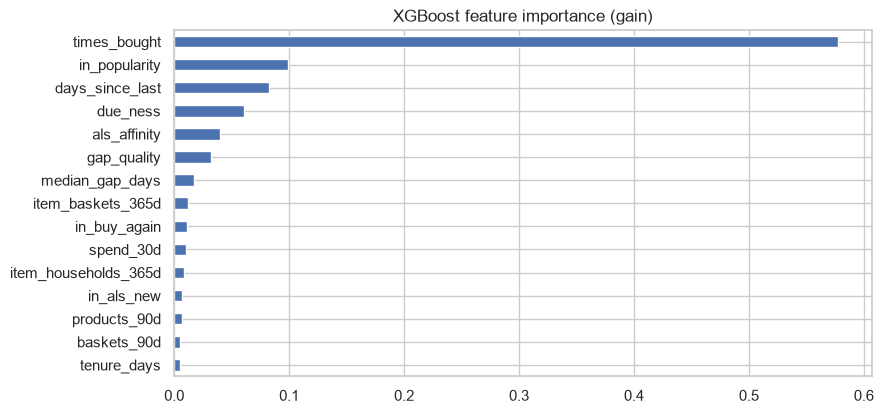

times_bought            0.5779
in_popularity           0.0987
days_since_last         0.0822
due_ness                0.0604
als_affinity            0.0401
gap_quality             0.0319
median_gap_days         0.0172
item_baskets_365d       0.0122
in_buy_again            0.0109
spend_30d               0.0107
item_households_365d    0.0081
in_als_new              0.0070
products_90d            0.0067
baskets_90d             0.0053
tenure_days             0.0050
spend_365d              0.0050
baskets_30d             0.0049
baskets_365d            0.0047
hh_days_since_last      0.0046
avg_basket_value        0.0037
item_avg_price          0.0025
dtype: float32


In [4]:
importance = (pd.Series(model.feature_importances_, index=FEATURES)
              .sort_values(ascending=False))
importance.head(15).plot.barh(title="XGBoost feature importance (gain)").invert_yaxis()
plt.show()
print(importance.round(4))

**Findings — XGBoost ranker (train 450/510/570, valid 600, K=10).**
recall@10 **0.104** vs buy-again 0.072 (+44% relative), hit_rate 0.856 vs
0.757, NDCG 0.436 vs 0.303, share of oracle ceiling 18% → **26%**. AUC-PR
0.302 against a 3.8% base rate; early stop at iteration 133 (flat curve —
features, not capacity, are binding). The two-stage architecture converts
pooled candidates into rank: every generator individually lost to buy-again;
fused and ranked, they beat it by 44%.

**Importance reading (gain):** times_bought 0.578 dominates; in_popularity
0.099 (carries information no other column has); days_since_last 0.082;
due_ness 0.060; als_affinity 0.040 — ALS failed as a model, succeeded as a
feature. Two structural observations: (1) `in_buy_again` ≈ 0.011 because it
is redundant with `times_bought > 0` — correlated features split credit;
(2) *all* customer-level features are ≈0.005 because they are **constant
within a household**, and ranking is within-household — such features can
only act through interactions.

**Decisions / next experiments:** within-household normalization of pair
features, and/or grouped LambdaMART (`rank:ndcg`), are the indicated
improvements; documented, not run — the plan says sealed-test evaluation next.
Caveat: early stopping used the validation plane, so these numbers carry mild
optimism; day 650 (notebook 90) is the clean verdict.

In [6]:
import json
REG = ROOT / "models" / "registry"
REG.mkdir(parents=True, exist_ok=True)

model.save_model(REG / "ranker.ubj")
(REG / "model_meta.json").write_text(json.dumps({
    "features": FEATURES,
    "trained_on_planes": CFG["snapshots"]["train"],
    "validated_on": CFG["snapshots"]["valid"],
    "best_iteration": int(model.best_iteration),
    "valid_aucpr": float(model.best_score),
    "valid_recall_at_10": float(new_row.loc["xgb_ranker", f"recall@{K}"]),
}, indent=2))
print("saved ->", REG)

saved -> C:\Users\siava\Recommendation_system\retail-recsys-platform\models\registry
